# Starting tests to model 2025wny

## Drive setup and imports

In [1]:
drive = False
NERSC = False
local = True

if drive:
    from google.colab import drive
    drive.mount('/content/drive')
    base_dir = '/content/drive/MyDrive/GL-PS-main'
if NERSC:
    base_dir = '/global/u1/o/osoler/repos/GL-PS'

if local:
    base_dir = '/Users/oscar/LB/GL-PS'

import os
import sys

os.chdir(base_dir)
%ls

README.md  modeling/  notebooks/ src/       test.txt


In [2]:
!nvidia-smi
# When running from google drive
if drive:
    !pip install corner
    !pip install lenstronomy==1.13.2
    !pip install gigalens --no-deps

# When running on NERSC
if NERSC:
    gigalens_base_dir = '/global/u1/o/osoler/gigalens/src'
    if gigalens_base_dir not in sys.path:
        sys.path.append(gigalens_base_dir)
        #print(sys.path)

zsh:1: command not found: nvidia-smi


In [3]:
# import modeling functions
from importlib import reload
import src.flux_ratios_pipeline_funcs
reload(src.flux_ratios_pipeline_funcs)
from src.flux_ratios_pipeline_funcs import *

# import gigalens functions
from gigalens.tf.inference import ModellingSequence
from gigalens.tf.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.tf.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.tf.profiles.light import sersic
from gigalens.tf.profiles.mass import sis, shear, epl, sie
from tensorflow_probability import distributions as tfd, bijectors as tfb

/Users/oscar/LB/GL-PS/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
/Users/oscar/LB/GL-PS/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


flux_ratios_pipeline_funcs.py version: 0.3.1
flux_ratios_pipeline_funcs.py version: 0.3.1


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredDirectionArrows
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.visualization.wcsaxes import add_scalebar
from astropy.stats import sigma_clipped_stats



## Observational data



In [5]:

data_dir = base_dir + '/modeling/2025wny/data/'
psfr_path = 'nirc2_psf_psfr_stacked.npy'
psf_path = 'nirc2_psf_stacked.npy'
image_fits = 'nirc2_wny_full.fits'
image_fits_clean = 'nirc2_wny_full_clean.fits'
psf_photutil_path = 'wny_photutil_psf_fit.csv'

with fits.open(data_dir + image_fits) as hdul:
  heads = hdul[0].header
  data = hdul[0].data
  hdul.close()

  heads_clean = hdul[0].header
  heads_list = ['CD1_1', 'CD1_2', 'CD2_1', 'CD2_2']
  for hl in heads_list:
    heads_clean[hl] = float(heads[hl])
  heads_clean['RADESYSa'] = heads['RADECSYS']
wcs = WCS(heads_clean)

psfr = np.load(data_dir + psfr_path)
psf = np.load(data_dir + psf_path)
psf_photutil = pd.read_csv(data_dir + psf_photutil_path)


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-BEG to 60990.630833 from DATE-BEG.
Set MJD-END to 60990.632953 from DATE-END'. [astropy.wcs.wcs]


In [6]:

psf_photutil

,Unnamed: 0,x_fit,y_fit,flux_fit,x_err,y_err,flux_err
0,0,491.346959,624.391736,60.829975,0.041131,0.045180,0.686246
1,1,433.149259,411.246418,17.631145,0.085960,0.094008,0.412534
2,2,634.350728,333.624255,14.024787,0.118965,0.131048,0.457709
3,3,884.289485,600.654906,8.869229,0.156156,0.172022,0.379112


In [ ]:
# psf_photutil['x_err'] = psf_photutil['x_err']+(0.004/0.009952)
# psf_photutil['y_err'] = psf_photutil['y_err']+(0.004/0.009952)

In [7]:
psf_photutil

,Unnamed: 0,x_fit,y_fit,flux_fit,x_err,y_err,flux_err
0,0,491.346959,624.391736,60.829975,0.041131,0.045180,0.686246
1,1,433.149259,411.246418,17.631145,0.085960,0.094008,0.412534
2,2,634.350728,333.624255,14.024787,0.118965,0.131048,0.457709
3,3,884.289485,600.654906,8.869229,0.156156,0.172022,0.379112


SKy mean: -8.86e-02, sky median: -8.88e-02, sky std: 4.88e-02


/var/folders/lp/gmwtz0k15l9131lfg2fd97bh0000gn/T/ipykernel_9767/1939223510.py:24: UserWarning: Adding colorbar to a different Figure <Figure size 800x800 with 2 Axes> than <Figure size 1000x500 with 2 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax = ax[0],


Text(0.5, 1.0, 'psf')

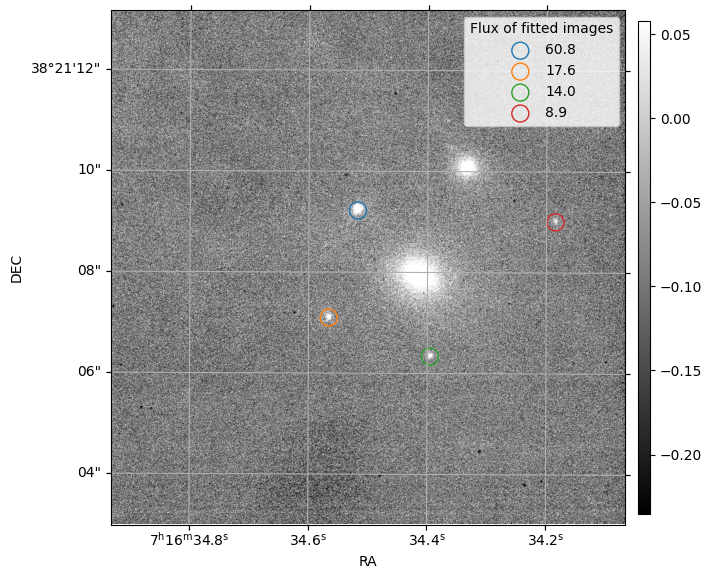

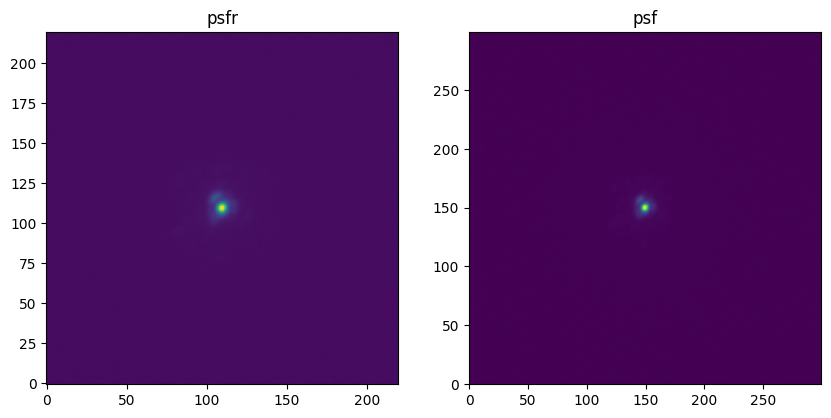

In [8]:
pixel_fit = np.array([psf_photutil['y_fit'].values, psf_photutil['x_fit'].values]).T
pixscale = 0.009952 # arcsec/px
exptime = 180

sky_mean, sky_median, sky_std = sigma_clipped_stats(data, sigma=3.0, maxiters=5)
print('SKy mean: %.2e, sky median: %.2e, sky std: %.2e'%(sky_mean, sky_median, sky_std))
bkg_rms = sky_std

stretch = 'linear'
percent = (5,99)
vminmax = (sky_mean - 3*sky_std,sky_mean + 3*sky_std)
# norm
norm = simple_norm(data, stretch,
                   #min_percent=percent[0], max_percent=percent[1],
                   #vmin = vminmax[0], vmax = vminmax[1])
                   min_cut = vminmax[0], max_cut = vminmax[1])
# figure
fig, ax = plt.subplots(1,1, figsize=(8,8))
fog, ax2 = plt.subplots(1,2, figsize=(10,5))
ax = [ax, ax2[0], ax2[1]]
ax[0].remove()
ax[0] = fig.add_subplot(1,1,1,projection=wcs)
im = ax[0].imshow(data, cmap='gray', origin = 'lower', norm = norm)
plt.colorbar(im, ax = ax[0],
             fraction = 0.15, aspect = 40, shrink = 0.8, pad = 0.02)
# images
for i in range(len(psf_photutil)):
  phot_row = psf_photutil.iloc[i]
  ax[0].scatter(phot_row['x_fit'], phot_row['y_fit'], label = '%.1f'%phot_row['flux_fit'],
             marker = 'o', s  = 150,
             facecolor = 'none', edgecolors=plt.get_cmap('tab10')(i), alpha = 1)
ax[0].legend(title = 'Flux of fitted images')
ax[0].set_xlabel('RA')
ax[0].set_ylabel('DEC')
ax[0].grid()
# psfs
ax[1].imshow(psfr, origin = 'lower')
ax[1].set_title('psfr')

ax[2].imshow(psf, origin = 'lower')
ax[2].set_title('psf')

[[625 491]
 [495 611]
 [709 709]]


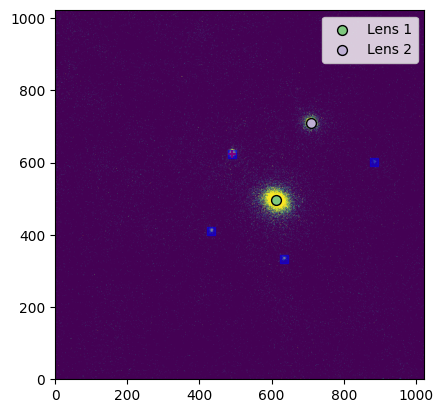

In [9]:
bp_converter = BrightestPoints(number_of_images = 3, num_pixels = data.shape[0],
                             grid_size = 50, delta_pix = pixscale,
                             supersample = 1)
bp_px = bp_converter.find_brightest_points(data)
print(bp_px.numpy())
plt.imshow(data, origin = 'lower', vmin=0, vmax = 0.1)
plt.scatter(bp_px[:,1], bp_px[:,0], c = 'r', marker='+')
plt.scatter(psf_photutil['x_fit'], psf_photutil['y_fit'], c = 'b', marker='s', alpha = 0.5)

lens1_px = bp_px[1]
lens2_px = bp_px[2]
pixel_lens = np.array([lens1_px, lens2_px])
for i, len_px in enumerate([lens1_px, lens2_px]):
  plt.scatter(len_px[1], len_px[0], marker='o', alpha = 1, s = 50, linewidths=1,
              edgecolors='black', facecolor = plt.get_cmap('Accent')(i), label = 'Lens %d'%(i+1))
plt.legend()

In [10]:

bp_converter = BrightestPoints(number_of_images = 4, num_pixels = data.shape[0],
                             grid_size = 20, delta_pix = pixscale,
                             supersample = 1)
x_arcsec, y_arcsec = bp_converter.pix_to_arcsec(pixel_fit)
x_arcsec_lens, y_arcsec_lens = bp_converter.pix_to_arcsec(pixel_lens)
print(x_arcsec, y_arcsec)

print(x_arcsec_lens, y_arcsec_lens)

flux_truth_test = tf.constant(psf_photutil['flux_fit'], dtype=tf.float32)
print(flux_truth_test)

tf.Tensor([-0.20401621 -0.78123224  1.2191198   3.70712   ], shape=(4,), dtype=float32) tf.Tensor([ 1.1195998  -1.0001762  -1.7764323   0.88075185], shape=(4,), dtype=float32)
tf.Tensor([0.9902238 1.9655199], shape=(2,), dtype=float32) tf.Tensor([-0.1642082  1.9655199], shape=(2,), dtype=float32)
tf.Tensor([60.829975 17.631145 14.024787  8.869228], shape=(4,), dtype=float32)


# Model



In [11]:
xy_lens_1 = tf.constant([x_arcsec_lens[0].numpy(), y_arcsec_lens[0].numpy()], dtype=tf.float32)
xy_lens_2 = tf.constant([x_arcsec_lens[1].numpy(), y_arcsec_lens[1].numpy()], dtype=tf.float32)

# Uniform prior
lens_prior_uniform = tfd.JointDistributionSequential(
  [tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 0.3, high = 3),
          e1=tfd.Uniform(-0.1, 0.1),
          e2=tfd.Uniform(-0.1, 0.1),
          center_x=tfd.Uniform(xy_lens_1[0]-0.2, xy_lens_1[0] + 0.2),
          center_y=tfd.Uniform(xy_lens_1[1]-0.2, xy_lens_1[1] + 0.2),
          )),
   tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 0.3, high = 3),
#           e1=tfd.Uniform(-0.1, 0.1),
          # e2=tfd.Uniform(-0.1, 0.1),
          center_x=tfd.Uniform(xy_lens_2[0]-0.2, xy_lens_2[0] + 0.2),
          center_y=tfd.Uniform(xy_lens_2[1]-0.2, xy_lens_2[1] + 0.2),
          )),
   tfd.JointDistributionNamed(
       dict(
           gamma1=tfd.Uniform(-0.1, 0.1),
           gamma2=tfd.Uniform(-0.1, 0.1),
          ),),])

# Normal distribution prior
lens_prior_norm = tfd.JointDistributionSequential(
  [tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 0.3, high = 3),
          e1=tfd.Normal(0, 0.1),
          e2=tfd.Normal(0, 0.1),
          center_x=tfd.Normal(xy_lens_1[0], 0.1),
          center_y=tfd.Normal(xy_lens_1[0], 0.1),
          )),
   tfd.JointDistributionNamed(
      dict(
          theta_E=tfd.Uniform(low = 0.3, high = 3),
          # e1=tfd.Normal(0, 0.1),
          # e2=tfd.Normal(0, 0.1),
          center_x=tfd.Normal(xy_lens_2[0], 0.1),
          center_y=tfd.Normal(xy_lens_2[0], 0.1),
          )),
   tfd.JointDistributionNamed(
       dict(
           gamma1=tfd.Normal(0.0, 0.05),
           gamma2=tfd.Normal(0.0, 0.05),
          ),),])

# physical model
phys_model = PhysicalModel(
    [ # mass profile
        sie.SIE(), # 50 is the maximum number of iterations for calculating the deflection
        sis.SIS(),
        shear.Shear() # External shear model, parameterized by shear components ``gamma1`` and ``gamma2``
    ],
    [ # lens light
        sersic.SersicEllipse(), # defined by e1, e2 and center_x, center_y
    ],
    [ # source light (Point() defined in functions)
        Point()
    ]
)

# truth configuration list
truth_test = [
    [ # mass distribution
        {'theta_E': 2.0, 'e1': 0.02, 'e2': 0.002, 'center_x': 1.17, 'center_y': 0.05},
        {'theta_E': 2.0, 'center_x': 1.17, 'center_y': 0.05},
        {'gamma1': 0.06, 'gamma2': 0.04}  # external shear
    ],
    [ # lensing galaxy light
        {'R_sersic': 0.350, 'n_sersic': 2.586, 'e1': -0.262, 'e2': 0.239, 'center_x': 0.011, 'center_y': -0.05, 'Ie': 250.055}
    ],
    [ # source light
        {'center_x': 1.17, 'center_y': 0.05, 'Ie': 2815.973}
    ]
]

Choosing a prior, creating the probabilistic model

In [12]:
lens_prior_chosen = lens_prior_uniform
prior = tfd.JointDistributionSequential([lens_prior_chosen,])
# resolution
supersample = 1
num_pix = data.shape[0]
# prob model without observed image
prob_model = ForwardProbModel(prior, 0, background_rms=bkg_rms, exp_time=exptime)
# example of sampling from the prob model
example1 = lens_prior_chosen.sample(seed = 1)
example2 = lens_prior_chosen.sample(seed = 2)
example3 = lens_prior_chosen.sample(seed = 3)
print('Sample parameters')
for ex in [example1, example2, example3]:
    print('-----------------')
    print_formatted_dict(ex)

# size = int(tf.size(tf.nest.flatten(example))|)
# kernel = np.load('/content/drive/MyDrive/point-source-updates/F475W-epsf.npy').astype(np.float32)
sim_config = SimulatorConfig(delta_pix=pixscale, num_pix=num_pix, supersample=supersample)

lens_sim = LensSimulator(phys_model, sim_config, bs=1)


Sample parameters
-----------------
 - theta_E   :    0.712278
   e2        :   -0.091938
   e1        :    0.033889
   center_y  :   -0.216726
   center_x  :    0.968989
 - theta_E   :    0.520200
   center_y  :    2.021967
   center_x  :    1.800997
 - gamma2    :    0.029317
   gamma1    :   -0.039653
-----------------
 - theta_E   :    2.591905
   e2        :   -0.040087
   e1        :    0.047536
   center_y  :   -0.072405
   center_x  :    1.027740
 - theta_E   :    0.971427
   center_y  :    2.164696
   center_x  :    1.813548
 - gamma2    :   -0.030241
   gamma1    :   -0.090865
-----------------
 - theta_E   :    1.270390
   e2        :   -0.078751
   e1        :   -0.080375
   center_y  :   -0.179969
   center_x  :    1.083025
 - theta_E   :    2.942235
   center_y  :    1.832987
   center_x  :    1.912557
 - gamma2    :   -0.012846
   gamma1    :   -0.016234


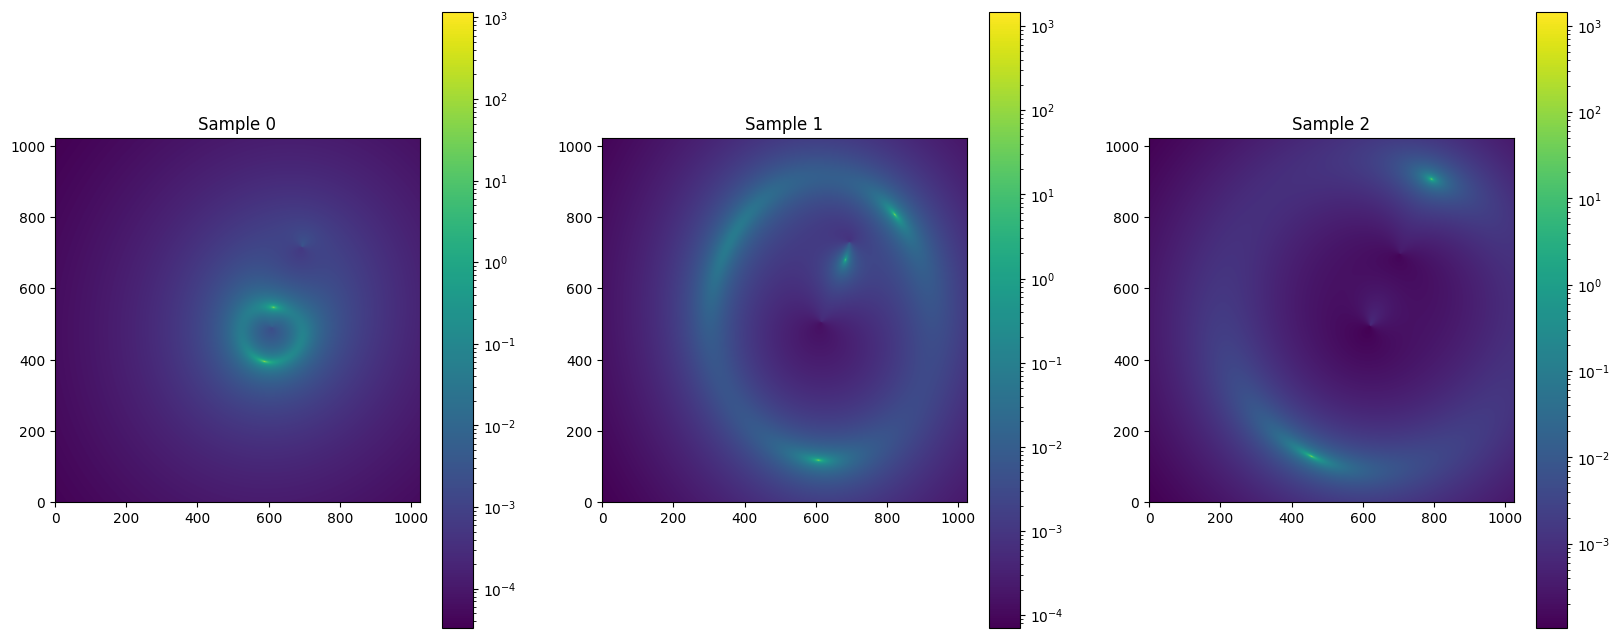

In [13]:
# simulated image with example of sampled mass distribution and truth source light
fig, ax = plt.subplots(1, 3, figsize=(20, 8))
for i, ex in enumerate([example1, example2, example3]):
  sim_image = lens_sim.simulate([ex, [], truth_test[2]])
  im = ax[i].imshow(sim_image, norm = 'log')#, vmin=0, vmax=10)
  plt.colorbar(im, ax = ax[i])
  ax[i].set_title('Sample %i'%i)
  ax[i].invert_yaxis()



    ============== weight_dist = 1.00e+03 | weight_flux = 1.00e+02 ==============


--- Modeling a real system ----


  0%|          | 0/3000 [00:00<?, ?it/s]


----- real system. comparing flux ratio difference ----

----- real system. comparing flux ratio difference ----


100%|██████████| 3000/3000 [00:10<00:00, 295.70it/s]



Best parameters:
 - theta_E   :    1.995111
   e2        :    0.290196
   e1        :   -0.022658
   center_y  :    0.423631
   center_x  :    1.443942
 - theta_E   :    0.374959
   center_y  :    1.953676
   center_x  :    2.037754
 - gamma2    :    0.262855
   gamma1    :   -0.056150


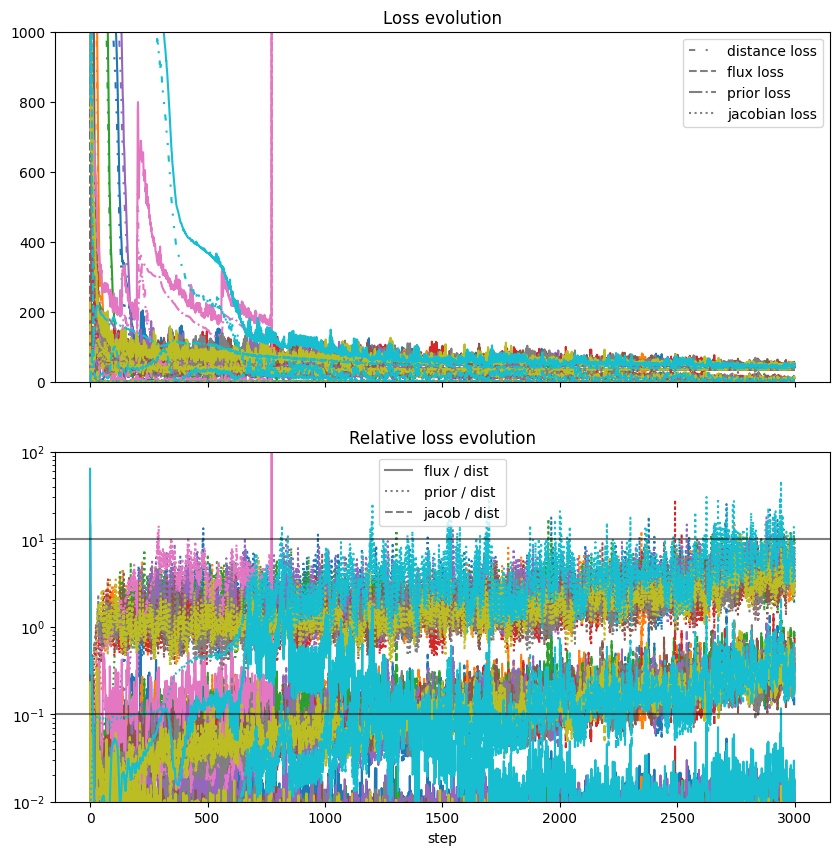


----- real system. comparing flux ratio difference ----


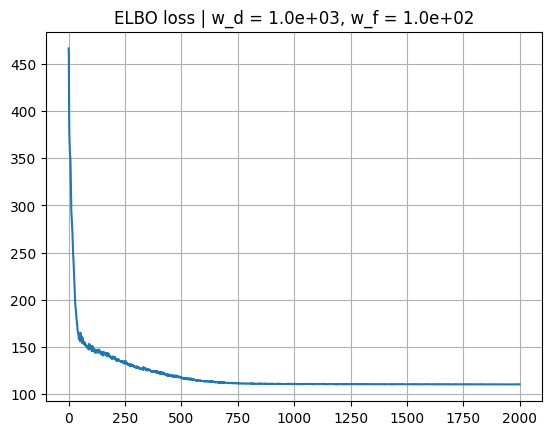

In [14]:
# resolution
supersample = 1
num_pix = data.shape[0]
delta_pix = pixscale

# Modeling
observed_data = [[x_arcsec, y_arcsec], flux_truth_test]

lens_prior_chosen = lens_prior_norm
prior = tfd.JointDistributionSequential([lens_prior_chosen,])
# prob model without observed image
prob_model = ForwardProbModel(prior, 0, background_rms=bkg_rms, exp_time=exptime)

# Uniform prior
prior_uniform = tfd.JointDistributionSequential([lens_prior_uniform,])
prob_model_uniform = ForwardProbModel(prior_uniform, 0, background_rms=bkg_rms, exp_time=exptime)
losses_list = []
for wd in [1e3]:#[1, 1e2, 1e4]: #, 1e1, 1e2]: #, 5e2, 1e3, 5e3]:
  for wf in [1e2]:#[1, 1e2, 1e4]: #, 5e2, 1e3, 5e3]:
    print('\n    ============== weight_dist = %.2e | weight_flux = %.2e ==============\n'%(wd,wf))
    analysis = LensModelAnalysis(delta_pix=pixscale, num_pix=num_pix, weight_dist=wd, weight_flux=wf, truth_test=truth_test,
                                prob_model=prob_model,
                                prior=prior,
                                #lens_prior = lens_prior,
                                phys_model = phys_model,
                                prob_model_uniform=prob_model_uniform,
                                observed_data = observed_data, simulation = False, flux_ratios = True)
    tf.debugging.set_log_device_placement(False)
    tf.config.run_functions_eagerly(False)  # make sure graph mode is on
    losses = analysis.run_map(n_map = 1000, n_steps = 3000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-1,
                                              'end_learning_rate': 1e-1/5, 'power': 1.0},
                    uniform_comparison = False,
                    track_loss_all = True,
                    test_results_dict = {'relative_errors': False,
                                         'plot_loss': True,
                                         'flux_ratio_error': False,
                                         'delensed_positions': False,},
                    return_loss = True)
    losses_list.append(losses)
    analysis.run_vi(n_vi = 1000, num_steps = 2000,
                    polynomial_decay_args = {'initial_learning_rate': 1e-2,
                                            'end_learning_rate': 1e-4,
                                            'power': 1.0})


In [ ]:
     samples_phys = analysis.run_hmc(n_hmc=32, num_burnin_steps=1200, num_results=6000, method = "adaptative",
                                     init_eps = 0.5, init_l = 3, max_leapfrog_steps = 50)